<p>
    <img src='../utils/digrams/eda_digram.png'>
</p>

# NYC Trip_Duration


#### This EDA for New York City Taxi Trip Duration project inspired by kaggle project to calculate the total duration for taxi driving in New York


#### from kaggle 
#### ***id*** - a unique identifier for each trip

#### ***vendor_id*** - a code indicating the provider associated with the trip record

#### ***dropoff_datetime*** - date and time when the meter was disengaged

#### ***passenger_count*** - the number of passengers in the vehicle (driver entered value)

#### ***pickup_longitude*** - the longitude where the meter was engaged

#### ***pickup_latitude*** - the latitude where the meter was engaged

#### ***dropoff_longitude*** - the longitude where the meter was disengaged

#### ***dropoff_latitude*** - the latitude where the meter was disengaged

#### ***store_and_fwd_flag*** - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip

#### ***trip_duration*** - duration of the trip in seconds



### Exploration


In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/split/train.csv')
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  str    
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  str    
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  str    
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 104.0 MB


In [8]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,1.534793,1.665353,-73.973475,40.750947,-73.973421,40.751829,9.548850e+02
std,0.498788,1.315723,0.065404,0.033745,0.065432,0.035782,3.882070e+03
min,1.000000,0.000000,-121.933342,34.359695,-121.933304,34.359695,1.000000e+00
25%,1.000000,1.000000,-73.991852,40.737372,-73.991341,40.735928,3.970000e+02
50%,2.000000,1.000000,-73.981728,40.754131,-73.979767,40.754551,6.620000e+02
75%,2.000000,2.000000,-73.967346,40.768379,-73.963036,40.769833,1.074000e+03
max,2.000000,7.000000,-61.335529,51.881084,-61.335529,43.921028,2.227612e+06


### Check missing values

In [9]:

df.isna().sum().sum()

np.int64(0)

### Check Dublicates 


In [10]:

df.duplicated().sum()

np.int64(0)

### Check Outliers

In [11]:

numberic_features = df.select_dtypes(np.number).columns

for feature in numberic_features:
    first_quartile = df[feature].quantile(0.25)
    third_quartile = df[feature].quantile(0.75)
    interquartile_range = third_quartile - first_quartile 

    lower_bount = first_quartile - (1.5 * interquartile_range)
    upper_bount = third_quartile + (1.5 * interquartile_range)
    mask = df[(df[feature] < lower_bount) | (df[feature] > upper_bount)]
    if not mask.empty:
        print(f"{feature} has outlier {len(mask)}")


passenger_count has outlier 106415
pickup_longitude has outlier 57641
pickup_latitude has outlier 36147
dropoff_longitude has outlier 53656
dropoff_latitude has outlier 49190
trip_duration has outlier 50939


In [12]:
print(df.shape)

for feature in numberic_features:
    first_quartile = df[feature].quantile(0.25)
    third_quartile = df[feature].quantile(0.75)
    interquartile_range = third_quartile - first_quartile 

    lower_bount = first_quartile - (1.5 * interquartile_range)
    upper_bount = third_quartile + (1.5 * interquartile_range)
    df[feature] = np.clip(df[feature], lower_bount, upper_bount)


(1000000, 10)


### EDA 

In [13]:

def info(col):
    print("min",df[col].min())
    print("max",df[col].max())
    print("Standard Deviation",df[col].std())
    print("Skewness",df[col].skew())
    Num_of_unique = df[col].nunique()
    print("Number of Unique Values",Num_of_unique)



In [14]:
def group_by(col,fun):
    return df.groupby(col)["trip_duration"].agg(fun).reset_index() #Aggregate our function 

### Trip Duration Anaylsis


In [15]:
Target = df.iloc[:,-1]
Target

0         1040.0
1          827.0
2          614.0
3          867.0
4         2089.5
           ...  
999995     254.0
999996     434.0
999997    1306.0
999998    2089.5
999999    1207.0
Name: trip_duration, Length: 1000000, dtype: float64

In [16]:
info("trip_duration")

min 1.0
max 2089.5
Standard Deviation 528.4156356643408
Skewness 0.9662751632353926
Number of Unique Values 2090


In [17]:
df["log_trip_duration"] = np.log1p(Target)
info("log_trip_duration")

min 0.6931471805599453
max 7.645158550796619
Standard Deviation 0.7485639386111104
Skewness -0.8473603361051122
Number of Unique Values 2090


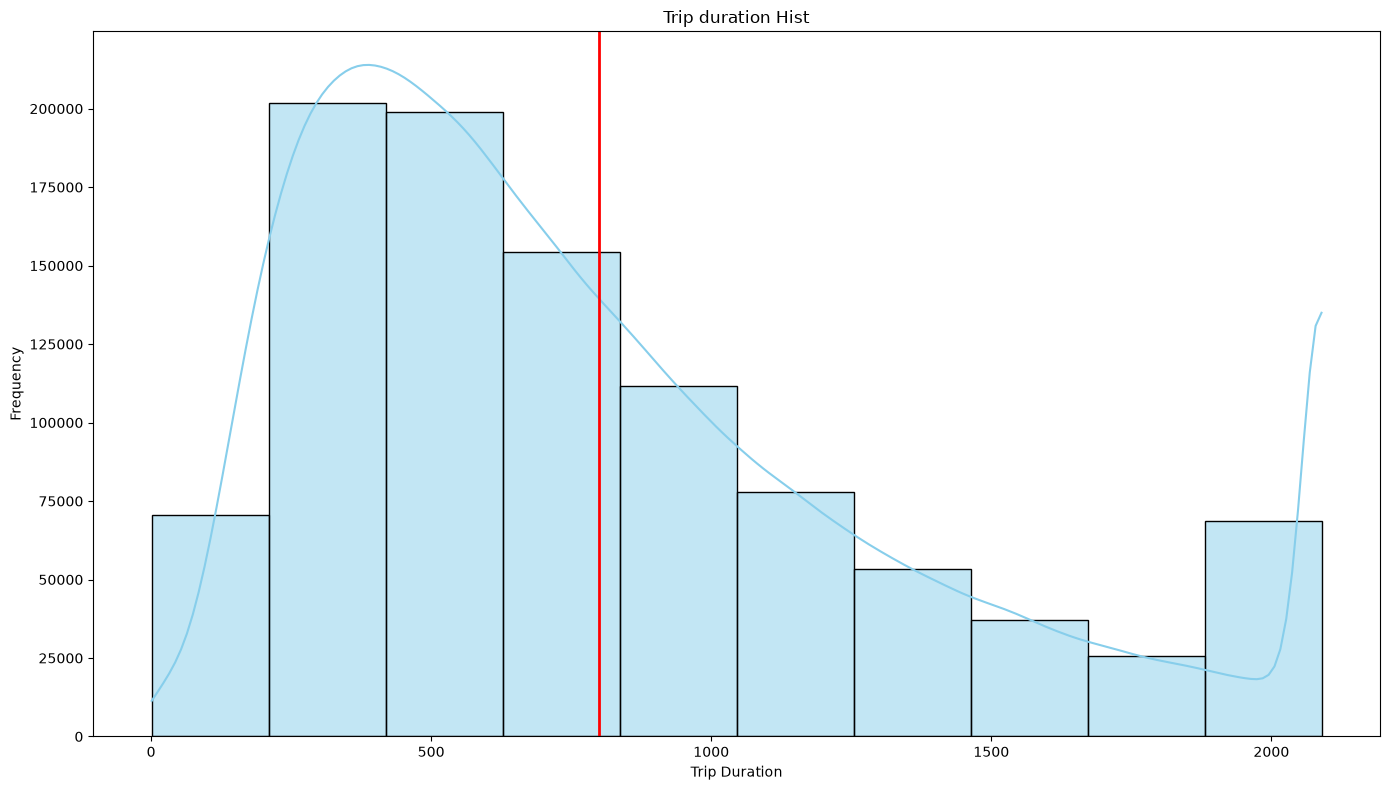

In [18]:
plt.figure(figsize=(14,8))

sns.histplot(Target, kde=True, bins=10, color="skyblue", edgecolor="black")
plt.axvline(Target.mean(), color="red", linewidth=2, label='Mean')


plt.title("Trip duration Hist")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Numerical Analysis

In [19]:
numberic_features

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'trip_duration'],
      dtype='str')

In [20]:
info("vendor_id")

min 1
max 2
Standard Deviation 0.498788227548221
Skewness -0.13951038803447147
Number of Unique Values 2


In [21]:
sum_vendor_id = group_by("vendor_id","count")
sum_vendor_id


,vendor_id,trip_duration
0,1,465207
1,2,534793


### passenger_count

In [22]:
info('passenger_count')

min 0.0
max 3.5
Standard Deviation 0.8550391010132895
Skewness 1.498481687995672
Number of Unique Values 5


In [23]:
total_passenger_count_during_trip = group_by("passenger_count","sum")
total_passenger_count_during_trip.sort_values(by="trip_duration", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds",subset=["trip_duration"])

,passenger_count,trip_duration
0,1.000000,560024903.500000
1,2.000000,119775422.500000
2,3.500000,86523150.000000
3,3.000000,33891800.000000
4,0.000000,6920.500000


D:\temp\ipykernel_5092\173218913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sum_vendor_id, x="vendor_id", y="trip_duration", palette="Reds", ax=axes[0])
D:\temp\ipykernel_5092\173218913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_passenger_count_during_trip, x="passenger_count", y="trip_duration", palette="Reds", ax=axes[1])


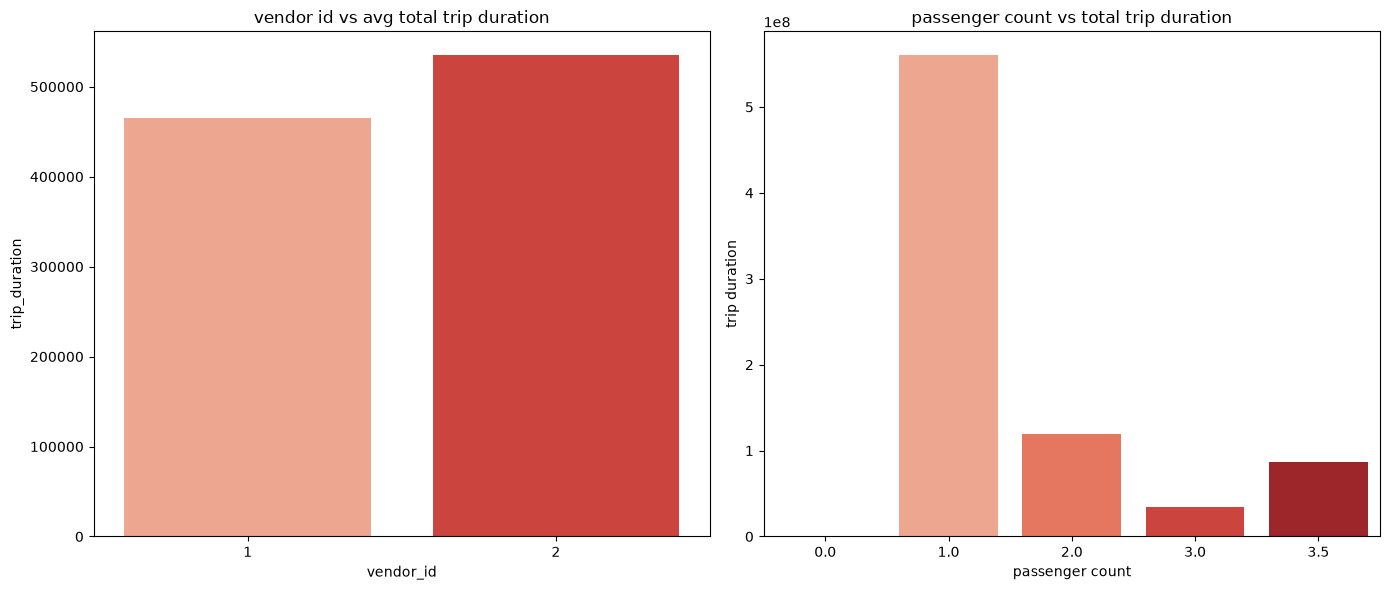

In [24]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.barplot(data=sum_vendor_id, x="vendor_id", y="trip_duration", palette="Reds", ax=axes[0])
axes[0].set_title("vendor id vs avg total trip duration")
axes[0].set_xlabel("vendor_id")
axes[0].set_ylabel("trip_duration")

sns.barplot(data=total_passenger_count_during_trip, x="passenger_count", y="trip_duration", palette="Reds", ax=axes[1])
axes[1].set_title("passenger count vs total trip duration")
axes[1].set_xlabel("passenger count")
axes[1].set_ylabel("trip duration")

plt.tight_layout()
plt.show()

In [25]:
df['passenger_count'].value_counts() 

passenger_count
1.0    708628
2.0    143907
3.5    106415
3.0     41012
0.0        38
Name: count, dtype: int64

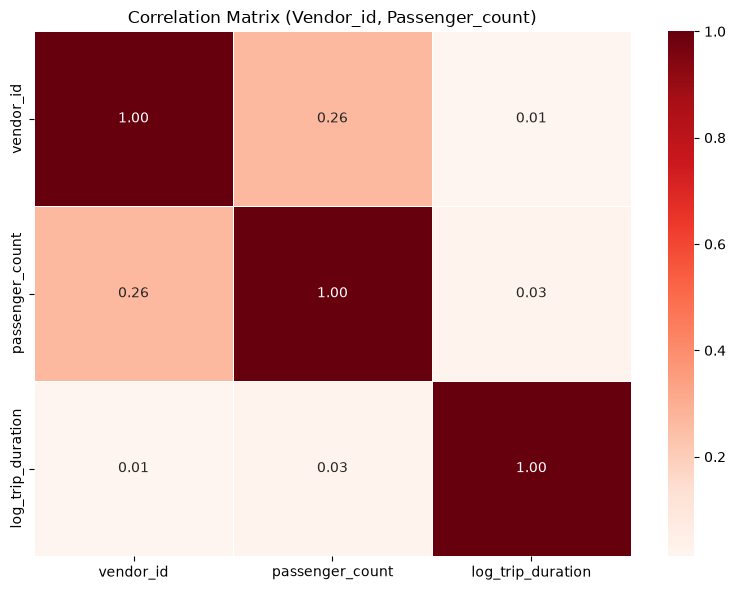

In [27]:
feats = df[["vendor_id","passenger_count","log_trip_duration"]]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Reds", fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix (Vendor_id, Passenger_count)")
plt.tight_layout()
plt.show()


#### Longitude & Latitude analysis

In [30]:
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

In [31]:
for feature in features:
    print("-"*10,feature,"-"*10)
    info(feature)

---------- pickup_longitude ----------
min -74.02861022949219
max -73.93058776855469
Standard Deviation 0.019911562111986504
Skewness 0.6598722865138452
Number of Unique Values 11493
---------- pickup_latitude ----------
min 40.690862178802504
max 40.81488943099974
Standard Deviation 0.024250863071563895
Skewness -0.32657166394136444
Number of Unique Values 31167
---------- dropoff_longitude ----------
min -74.03379821777341
max -73.92057800292972
Standard Deviation 0.022416695851162603
Skewness 0.6845382761752637
Number of Unique Values 13643
---------- dropoff_latitude ----------
min 40.6850700378418
max 40.8206901550293
Standard Deviation 0.028076144537175836
Skewness -0.22000037015367355
Number of Unique Values 34946


In [ ]:
y = df['trip_duration']

plt.figure(figsize=(14,22))

for i in range(4):
    ax = plt.subplot(2,2,i+1)
    hb = ax.hexbin
